In [30]:
import math
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq



In [31]:

data = yf.download("BHARTIARTL.NS", start="2025-03-07", end="2026-03-07",auto_adjust=True)
data = pd.DataFrame(data)
closing_prices = data["Close"]
daily_returns = closing_prices.pct_change()

[*********************100%***********************]  1 of 1 completed


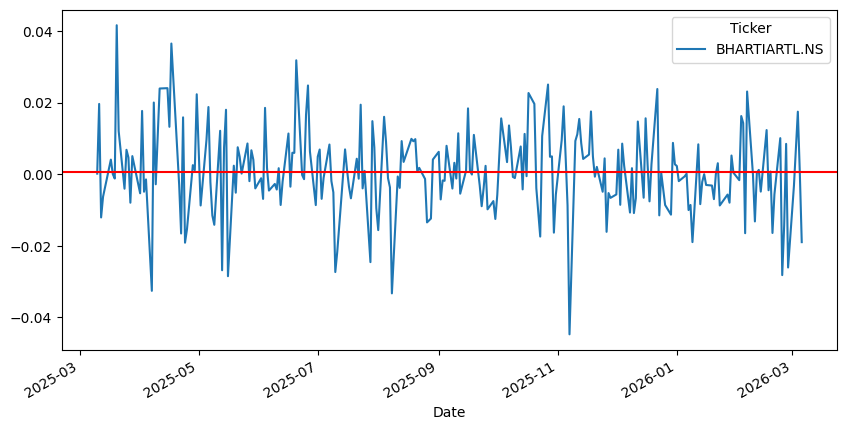

In [32]:
daily_returns = daily_returns.dropna()
daily_mean = daily_returns.mean()
daily_std = daily_returns.std()
annualized_std = daily_std * math.sqrt(252)
daily_returns.plot(figsize=(10,5))
plt.axhline(y=daily_mean.item(), color='r', label=f'Mean: {daily_mean.item():.2f}')
plt.show()

In [33]:
closing_prices.tail(1)

Ticker,BHARTIARTL.NS
Date,
2026-03-06,1870.800049


In [34]:
def black_scholes_price(S0,K,r,T1,t0,sigma):
  T = (T1-t0).days/252
  d2 = ((math.log(S0/K) + (r - (0.5 * annualized_std.item()**2)) * T)) / (annualized_std.item() * math.sqrt(T))
  d1 = d2 + (annualized_std.item() * math.sqrt(T))
  C = (S0 * norm.cdf(d1)) - (math.exp(-r * T) * K * norm.cdf(d2))
  print(d2)
  print(d1)
  print(f'The option price is:{C}')
  return C




In [35]:
S0= 1871  #round(closing_prices.iloc[-1]).astype(int)#spot price at t
K = 1900 #strike price
r = 6.68/100 # risk free rate
T1 = date(2026, 3,26 ) #expiry
t0 = date(2026, 3, 7) #todays date
T = (T1-t0).days/252
sigma = annualized_std
market_price = 51.75



In [36]:
black_schole_call_price = black_scholes_price(S0,K,r,T1,t0,sigma)
print(f'{Black_Schole_Price:.2f} is the Back Schole Price')


-0.2232426593592374
-0.17072967835123426
The option price is:30.430411326459875
30.43 is the Back Schole Price


In [37]:
def black_scholes_call(S0,K,r,T,sigma):
    d1 = (math.log(S0/K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

def vega(S0,K,r,T,sigma):
    d1 = (math.log(S0/K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return S0 * math.sqrt(T) * norm.pdf(d1)


# Step 3a: Newton-Raphson method
def iv_newton(market_price, S0, K, T, r, tol=1e-6, max_iter=100):
    sigma = 0.2  # initial guess
    for i in range(max_iter):
        price = black_scholes_call(S0,K,r,T,sigma)
        v = vega(S0,K,r,T,sigma)
        diff = market_price - price
        if abs(diff) < tol:
            return sigma
        sigma += diff / v   # update step
    return sigma

# Step 3b: Brentq method (more robust)
def iv_brentq(market_price, S0, K, T, r):
    objective = lambda sigma: black_scholes_call(S0,K,r,T,sigma) - market_price
    return brentq(objective, 1e-6, 10.0)  # search between 0% and 1000% vol




In [40]:
ivb = iv_brentq(market_price, S0, K, T, r)
ivnr = iv_newton(market_price, S0, K, T, r, tol=1e-6, max_iter=100)
print(f"Sigma {annualized_std.item()*100 :.2f}%")
print(f"Implied Volatility brentq: {ivb*100:.3f}%")
print(f"Implied Volatility newton raphson: {ivnr*100:.2f}%")

Sigma 19.12%
Implied Volatility brentq: 29.609%
Implied Volatility newton raphson: 29.61%
